# Probabilistic Automata Benchmark for the Bottleneck Graphicalizer

This notebook is the stronger benchmark for the graph interpretation bottleneck. Unlike the visual sanity notebook, this one trains a tiny sequence transformer on observed symbols, freezes it, then trains the bottleneck graphicalizer on transformer token embeddings.

The benchmark asks whether the learned graph recovers the hidden state-transition graph of a probabilistic finite-state generator. It compares an identifiable automaton, where states have distinctive emissions, with a harder ambiguous automaton, where emissions overlap.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]
repo_root


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/abstractgraph-ecosystem/repos/abstractgraph-graphicalizer')

In [2]:
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
import numpy as np
import torch

from abstractgraph_graphicalizer.bottleneck import (
    BottleneckGraphicalizer,
    aggregate_bottleneck_graphs,
    HiddenAutomaton,
    collapse_graph_to_states,
    edge_recovery_diagnostics,
    extract_sequence_embeddings,
    generate_automaton_sequences,
    state_assignment_diagnostics,
    train_tiny_sequence_transformer,
    transition_graph_from_assignments,
)

plt.rcParams.update({
    "figure.figsize": (13, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 11
np.random.seed(SEED)
torch.manual_seed(SEED)


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


## Benchmark Helpers

Each run creates a sparse probabilistic labelled transition system, generates symbol sequences while recording hidden states, trains a transformer for next-symbol prediction, and then graphicalizes frozen transformer embeddings.


In [3]:
def make_sparse_transition_matrix(n_states, *, stay=0.04, main=0.76, skip=0.20):
    transitions = np.zeros((n_states, n_states), dtype=float)
    for state in range(n_states):
        transitions[state, state] = stay
        transitions[state, (state + 1) % n_states] = main
        transitions[state, (state + 2) % n_states] = skip
    transitions /= transitions.sum(axis=1, keepdims=True)
    return transitions


def make_emission_matrix(n_states, symbols_per_state=2, *, sharpness=0.92, overlap=0.0):
    vocab_size = n_states * symbols_per_state
    emissions = np.full((n_states, vocab_size), 1e-4, dtype=float)
    for state in range(n_states):
        owned = list(range(state * symbols_per_state, (state + 1) * symbols_per_state))
        emissions[state, owned] += sharpness / symbols_per_state
        if overlap > 0.0:
            neighbour = (state + 1) % n_states
            neighbour_symbols = list(range(neighbour * symbols_per_state, (neighbour + 1) * symbols_per_state))
            emissions[state, neighbour_symbols] += overlap / symbols_per_state
    emissions /= emissions.sum(axis=1, keepdims=True)
    return emissions


def make_automaton(n_states=5, symbols_per_state=2, *, emission_sharpness=0.92, emission_overlap=0.0):
    transitions = make_sparse_transition_matrix(n_states)
    emissions = make_emission_matrix(
        n_states,
        symbols_per_state,
        sharpness=emission_sharpness,
        overlap=emission_overlap,
    )
    start = np.full(n_states, 1.0 / n_states)
    return HiddenAutomaton(
        transition_probs=transitions,
        emission_probs=emissions,
        start_probs=start,
        symbols=tuple(range(emissions.shape[1])),
    )


def true_transition_graph(automaton, threshold=0.05):
    graph = nx.DiGraph()
    for state in range(automaton.n_states):
        graph.add_node(state, label=f"s{state}")
    for src in range(automaton.n_states):
        for dst in range(automaton.n_states):
            probability = float(automaton.transition_probs[src, dst])
            if probability >= threshold:
                graph.add_edge(src, dst, probability=probability, weight=probability)
    return graph


In [4]:
def true_transition_graph(automaton, threshold=0.05):
    return automaton.transition_graph(threshold=threshold)


def graph_from_assignments(graphs, sequences=None, *, top_k_per_source=3, min_count=8):
    assignments = [graph.graph["token_to_nodes"] for graph in graphs]
    return transition_graph_from_assignments(
        assignments,
        tokens=sequences,
        top_k_per_source=top_k_per_source,
        min_count=min_count,
    )


In [5]:
def draw_graph(ax, graph, pos, title, *, node_labels=None, node_colors=None, edge_label="probability"):
    if node_colors is None:
        node_colors = "#8ecae6"
    widths = [1.0 + 5.0 * float(graph.edges[e].get("probability", graph.edges[e].get("weight", 0.1))) for e in graph.edges()]
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=850, edgecolors="#222", linewidths=1.0, ax=ax)
    nx.draw_networkx_edges(
        graph,
        pos,
        width=widths,
        edge_color="#555",
        arrows=True,
        arrowsize=16,
        connectionstyle="arc3,rad=0.10",
        ax=ax,
    )
    nx.draw_networkx_labels(graph, pos, labels=node_labels, font_size=9, font_weight="bold", ax=ax)
    labels = {edge: f"{float(graph.edges[edge].get(edge_label, 0.0)):.2f}" for edge in graph.edges()}
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=labels, font_size=7, ax=ax, label_pos=0.55)
    ax.set_title(title)
    ax.set_axis_off()


def plot_run(result):
    true_graph = result["true_graph"]
    proto_graph = result["prototype_graph"]
    collapsed = result["collapsed_graph"]
    n_states = result["automaton"].n_states
    palette = plt.cm.Set2(np.linspace(0, 1, n_states))

    true_pos = nx.circular_layout(true_graph)
    proto_pos = nx.spring_layout(proto_graph, seed=SEED, k=1.1)
    proto_colors = [palette[result["proto_to_state"].get(int(node), 0)] for node in proto_graph.nodes()]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    draw_graph(
        axes[0],
        true_graph,
        true_pos,
        f"{result['name']}: true automaton",
        node_labels={node: f"s{node}" for node in true_graph.nodes()},
        node_colors=[palette[node] for node in true_graph.nodes()],
    )
    draw_graph(
        axes[1],
        proto_graph,
        proto_pos,
        "learned prototype transitions",
        node_labels={node: f"p{node}\ns{result['proto_to_state'].get(int(node), '?')}" for node in proto_graph.nodes()},
        node_colors=proto_colors,
    )
    draw_graph(
        axes[2],
        collapsed,
        true_pos,
        "collapsed to matched states",
        node_labels={node: f"s{node}" for node in collapsed.nodes()},
        node_colors=[palette[node] for node in collapsed.nodes()],
    )
    plt.tight_layout()
    plt.show()

    true_adj = nx.to_numpy_array(true_graph, nodelist=list(range(n_states)), weight="probability")
    learned_adj = nx.to_numpy_array(collapsed, nodelist=list(range(n_states)), weight="probability")
    black_blue_cmap = LinearSegmentedColormap.from_list("black_to_blue", ["#000000", "#0033cc"])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, mat, title in zip(axes, [true_adj, learned_adj], ["true adjacency", "learned collapsed adjacency"]):
        im = ax.imshow(mat, cmap=black_blue_cmap, vmin=0.0)
        ax.set_title(title)
        ax.set_xlabel("destination")
        ax.set_ylabel("source")
        ax.set_xticks(range(n_states))
        ax.set_yticks(range(n_states))
        for row in range(mat.shape[0]):
            for col in range(mat.shape[1]):
                if mat[row, col] > 0:
                    ax.text(col, row, f"{mat[row, col]:.2f}", ha="center", va="center", color="white", fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


## Run One Benchmark Condition

The function below runs the full benchmark for one emission regime. The transformer is trained only on symbols; hidden states are used only for post-hoc evaluation and plotting.


In [6]:
def run_condition(
    name,
    *,
    emission_sharpness,
    emission_overlap,
    n_states=5,
    symbols_per_state=2,
    n_sequences=96,
    length=36,
    transformer_epochs=4,
    bottleneck_epochs=8,
    lambda_transition=0.00,
    lambda_transition_bce=0.10,
    lambda_transition_kl=0.10,
    lambda_balance=0.00,
    message_edge_mode="learned",
    seed=SEED,
):
    np.random.seed(seed)
    torch.manual_seed(seed)
    automaton = make_automaton(
        n_states=n_states,
        symbols_per_state=symbols_per_state,
        emission_sharpness=emission_sharpness,
        emission_overlap=emission_overlap,
    )
    data = generate_automaton_sequences(
        automaton,
        n_sequences=n_sequences,
        length=length,
        random_state=seed + 1,
    )

    sequence_encoder = train_tiny_sequence_transformer(
        data["sequences"],
        vocab_size=automaton.vocab_size,
        d_model=32,
        n_heads=4,
        num_layers=2,
        n_epochs=transformer_epochs,
        lr=2e-3,
        device="cpu",
    )
    embeddings = extract_sequence_embeddings(sequence_encoder, data["sequences"], device="cpu")

    graphicalizer = BottleneckGraphicalizer(
        d_model=32,
        num_prototypes=max(12, n_states * 3),
        use_encoder=False,
        n_epochs=bottleneck_epochs,
        lr=2e-3,
        output_graph="directed",
        active_only=True,
        top_k_edges=3,
        edge_threshold=0.25,
        gnn_layers=2,
        hidden_dim=48,
        temperature=0.05,
        node_mask_ratio=0.2,
        token_mask_ratio=0.2,
        lambda_token=0.2,
        lambda_sparse=0.03,
        lambda_binary=0.01,
        lambda_entropy=0.05,
        lambda_transition=lambda_transition,
        lambda_transition_bce=lambda_transition_bce,
        lambda_transition_kl=lambda_transition_kl,
        lambda_balance=lambda_balance,
        message_edge_mode=message_edge_mode,
        device="cpu",
    )
    graphs = graphicalizer.fit_transform(embeddings)
    assignments = [graph.graph["token_to_nodes"] for graph in graphs]
    state_diagnostics = state_assignment_diagnostics(assignments, data["hidden_states"])
    state_scores = state_diagnostics["metrics"]
    proto_to_state = state_diagnostics["majority_state"]
    predicted_graph = aggregate_bottleneck_graphs(
        graphs,
        min_edge_frequency=0.10,
        top_k_per_source=3,
    )
    assignment_graph = graph_from_assignments(
        graphs,
        data["sequences"],
        top_k_per_source=3,
        min_count=6,
    )
    collapsed_predicted_graph = collapse_graph_to_states(
        predicted_graph,
        proto_to_state,
        automaton.n_states,
        top_k_per_source=3,
    )
    collapsed_assignment_graph = collapse_graph_to_states(
        assignment_graph,
        proto_to_state,
        automaton.n_states,
        top_k_per_source=3,
    )
    truth = true_transition_graph(automaton, threshold=0.05)
    predicted_scores = {
        f"predicted_{key}": value
        for key, value in edge_recovery_diagnostics(
            truth,
            collapsed_predicted_graph,
            n_states=automaton.n_states,
        ).items()
    }
    assignment_scores = {
        f"assignment_{key}": value
        for key, value in edge_recovery_diagnostics(
            truth,
            collapsed_assignment_graph,
            n_states=automaton.n_states,
        ).items()
    }
    return {
        "name": name,
        "automaton": automaton,
        "data": data,
        "graphs": graphs,
        "assignments": assignments,
        "proto_to_state": proto_to_state,
        "true_graph": truth,
        "prototype_graph": assignment_graph,
        "predicted_graph": predicted_graph,
        "collapsed_graph": collapsed_assignment_graph,
        "collapsed_predicted_graph": collapsed_predicted_graph,
        "training_history": graphicalizer.training_history_,
        "message_edge_mode": message_edge_mode,
        "metrics": {**state_scores, **predicted_scores, **assignment_scores},
    }


## Distinctive Emissions

This is the statistically identifiable setting: each hidden state has a distinctive emission distribution. Good recovery here means the transformer and graphicalizer pipeline can recover the planted graph when the data contains enough information.


In [7]:
distinctive = run_condition(
    "distinctive emissions",
    emission_sharpness=0.94,
    emission_overlap=0.00,
)
distinctive["metrics"]


{'clustering_accuracy': 0.8185763888888888,
 'purity': 0.9901620370370371,
 'ari': 0.8130738754903297,
 'nmi': 0.8595688666770395,
 'n_learned_nodes': 10.0,
 'n_true_states': 5.0,
 'mean_prototype_state_entropy': 0.0344273904797964,
 'max_prototypes_per_state': 3.0,
 'predicted_edge_precision': 0.2857142857142857,
 'predicted_edge_recall': 0.2,
 'predicted_edge_auroc': 0.4,
 'predicted_edge_symmetric_difference': 13.0,
 'predicted_vf2_isomorphic_unlabelled': False,
 'assignment_edge_precision': 0.9090909090909091,
 'assignment_edge_recall': 1.0,
 'assignment_edge_auroc': 1.0,
 'assignment_edge_symmetric_difference': 1.0,
 'assignment_vf2_isomorphic_unlabelled': False}

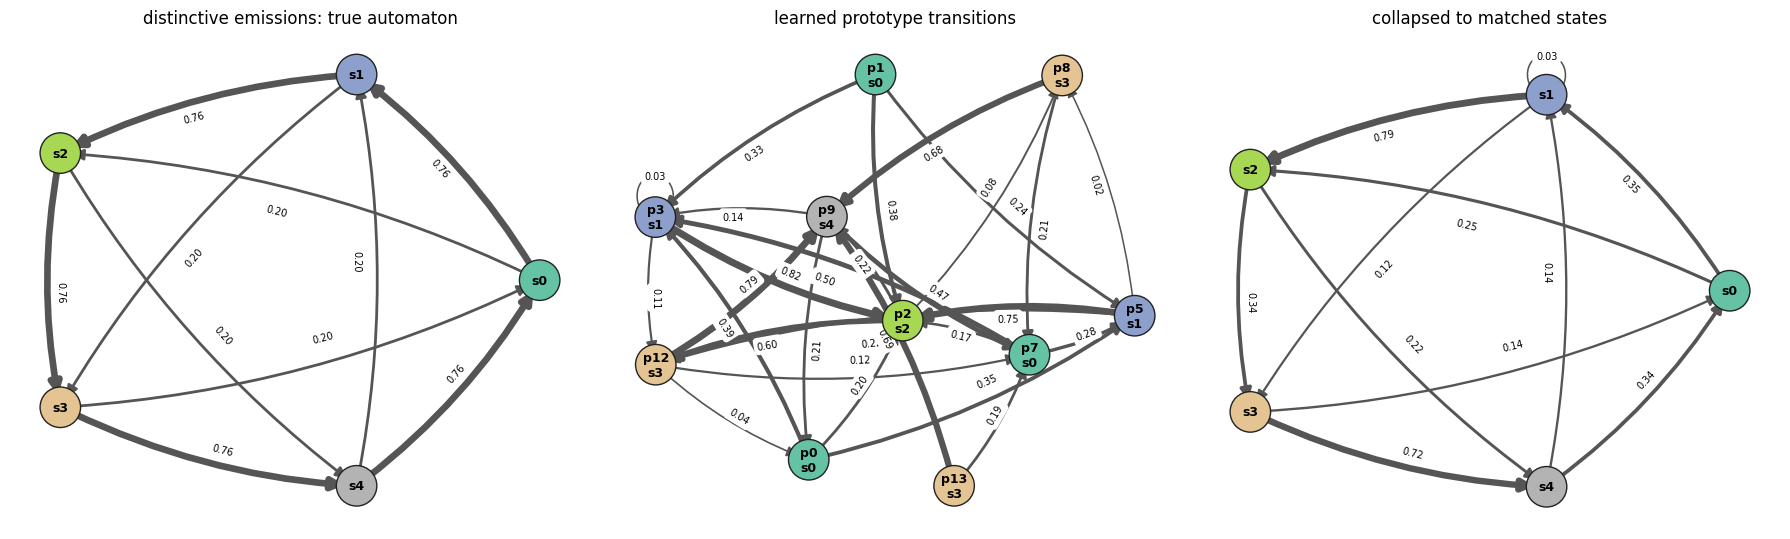

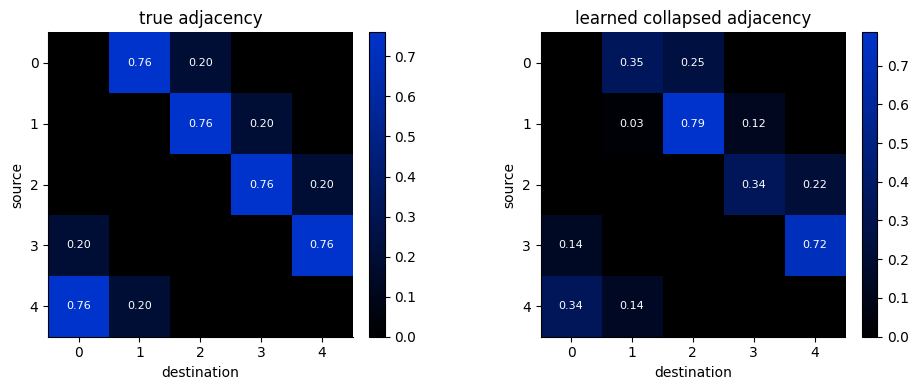

In [8]:
plot_run(distinctive)


## Ambiguous Emissions

This harder setting gives each state some probability mass on the next state's symbols. Recovery is not guaranteed: the purpose is to see degradation as identifiability weakens.


In [9]:
ambiguous = run_condition(
    "ambiguous emissions",
    emission_sharpness=0.76,
    emission_overlap=0.18,
    seed=SEED + 20,
)
ambiguous["metrics"]


{'clustering_accuracy': 0.5853587962962963,
 'purity': 0.6869212962962963,
 'ari': 0.3950045814619763,
 'nmi': 0.5042814074252492,
 'n_learned_nodes': 13.0,
 'n_true_states': 5.0,
 'mean_prototype_state_entropy': 0.6672957517284351,
 'max_prototypes_per_state': 4.0,
 'predicted_edge_precision': 0.42857142857142855,
 'predicted_edge_recall': 0.6,
 'predicted_edge_auroc': 0.5666666666666667,
 'predicted_edge_symmetric_difference': 12.0,
 'predicted_vf2_isomorphic_unlabelled': False,
 'assignment_edge_precision': 0.7142857142857143,
 'assignment_edge_recall': 1.0,
 'assignment_edge_auroc': 0.9133333333333333,
 'assignment_edge_symmetric_difference': 4.0,
 'assignment_vf2_isomorphic_unlabelled': False}

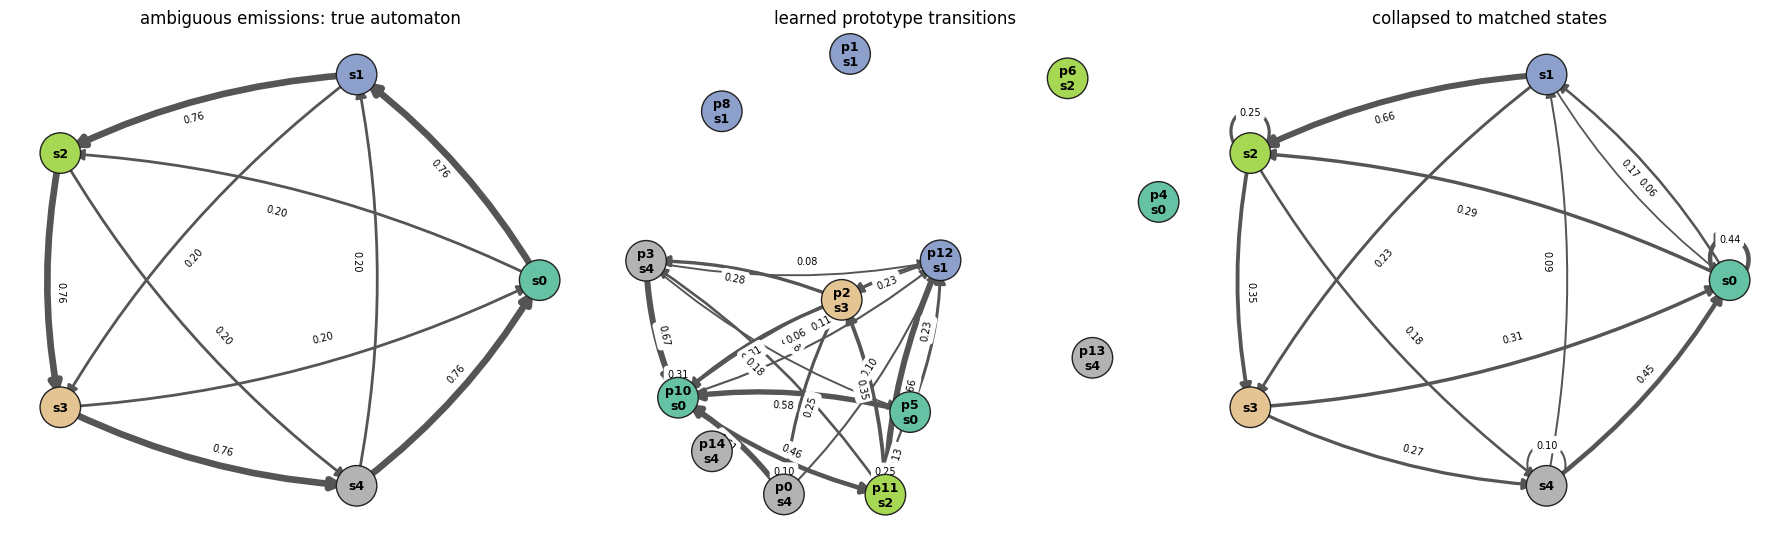

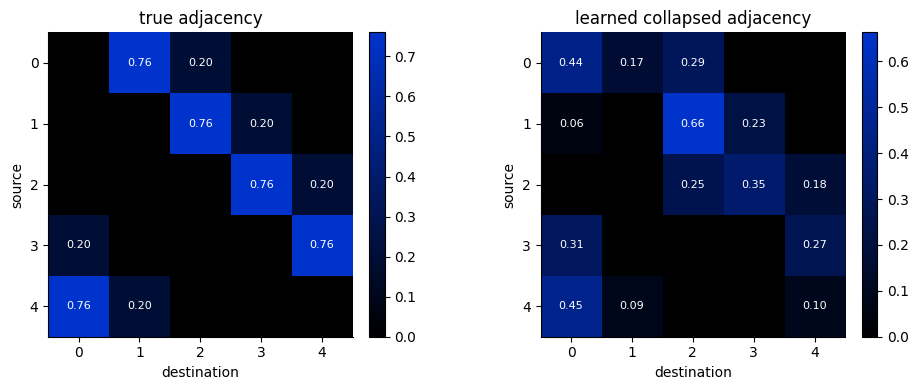

In [10]:
plot_run(ambiguous)


## Edge-Mode and Objective Ablations

This ablation keeps the distinctive automaton small and fixed. It compares the message-passing graph itself (`message_edge_mode`) and the transition-alignment objective. The `transition` edge mode is an oracle-style upper bound for sequence benchmarks because it uses consecutive prototype assignments directly for message passing; it does not use hidden automaton states.


In [11]:
ablation_settings = [
    {"label": "learned_reconstruction", "mode": "learned", "lambda_transition": 0.00, "lambda_transition_bce": 0.00, "lambda_transition_kl": 0.00, "lambda_balance": 0.00},
    {"label": "learned_transition_mse", "mode": "learned", "lambda_transition": 0.10, "lambda_transition_bce": 0.00, "lambda_transition_kl": 0.00, "lambda_balance": 0.00},
    {"label": "learned_transition_heads", "mode": "learned", "lambda_transition": 0.00, "lambda_transition_bce": 0.10, "lambda_transition_kl": 0.10, "lambda_balance": 0.00},
    {"label": "transition_edges_upper", "mode": "transition", "lambda_transition": 0.00, "lambda_transition_bce": 0.00, "lambda_transition_kl": 0.00, "lambda_balance": 0.00},
    {"label": "dense_edges", "mode": "dense", "lambda_transition": 0.00, "lambda_transition_bce": 0.00, "lambda_transition_kl": 0.00, "lambda_balance": 0.00},
    {"label": "random_edges", "mode": "random", "lambda_transition": 0.00, "lambda_transition_bce": 0.00, "lambda_transition_kl": 0.00, "lambda_balance": 0.00},
    {"label": "no_edges", "mode": "none", "lambda_transition": 0.00, "lambda_transition_bce": 0.00, "lambda_transition_kl": 0.00, "lambda_balance": 0.00},
]

ablation_rows = []
for seed_offset in range(3):
    for spec in ablation_settings:
        result = run_condition(
            spec["label"],
            emission_sharpness=0.94,
            emission_overlap=0.00,
            n_sequences=48,
            length=28,
            transformer_epochs=2,
            bottleneck_epochs=4,
            lambda_transition=spec["lambda_transition"],
            lambda_transition_bce=spec["lambda_transition_bce"],
            lambda_transition_kl=spec["lambda_transition_kl"],
            lambda_balance=spec["lambda_balance"],
            message_edge_mode=spec["mode"],
            seed=SEED + 100 + seed_offset,
        )
        metrics = result["metrics"]
        final_losses = result["training_history"][-1]
        ablation_rows.append({
            "label": spec["label"],
            "seed": seed_offset,
            "loss": final_losses["loss"],
            "loss_node": final_losses["loss_node"],
            "loss_token": final_losses["loss_token"],
            "ari": metrics["ari"],
            "nmi": metrics["nmi"],
            "predicted_edge_auroc": metrics["predicted_edge_auroc"],
            "predicted_edge_recall": metrics["predicted_edge_recall"],
            "assignment_edge_auroc": metrics["assignment_edge_auroc"],
            "max_prototypes_per_state": metrics["max_prototypes_per_state"],
        })

def summarize(rows, label):
    selected = [row for row in rows if row["label"] == label]
    summary = {"label": label}
    for key in selected[0]:
        if key in {"label", "seed"}:
            continue
        values = np.asarray([row[key] for row in selected], dtype=float)
        summary[key + "_mean"] = float(values.mean())
        summary[key + "_std"] = float(values.std())
    return summary

ablation_summary = [summarize(ablation_rows, spec["label"]) for spec in ablation_settings]
for row in ablation_summary:
    print(
        f"{row['label']:26s} "
        f"loss={row['loss_mean']:.3f}+/-{row['loss_std']:.3f} "
        f"ARI={row['ari_mean']:.3f}+/-{row['ari_std']:.3f} "
        f"pred_AUROC={row['predicted_edge_auroc_mean']:.3f}+/-{row['predicted_edge_auroc_std']:.3f} "
        f"pred_recall={row['predicted_edge_recall_mean']:.3f}+/-{row['predicted_edge_recall_std']:.3f} "
        f"assign_AUROC={row['assignment_edge_auroc_mean']:.3f}+/-{row['assignment_edge_auroc_std']:.3f}"
    )


learned_reconstruction     loss=0.839+/-0.100 ARI=0.929+/-0.054 pred_AUROC=0.577+/-0.111 pred_recall=0.467+/-0.236 assign_AUROC=1.000+/-0.000
learned_transition_mse     loss=0.836+/-0.078 ARI=0.864+/-0.103 pred_AUROC=0.498+/-0.060 pred_recall=0.300+/-0.082 assign_AUROC=0.989+/-0.011
learned_transition_heads   loss=1.439+/-0.154 ARI=0.766+/-0.092 pred_AUROC=0.483+/-0.064 pred_recall=0.200+/-0.082 assign_AUROC=0.982+/-0.021
transition_edges_upper     loss=0.327+/-0.018 ARI=0.981+/-0.009 pred_AUROC=0.870+/-0.065 pred_recall=0.900+/-0.082 assign_AUROC=1.000+/-0.000
dense_edges                loss=0.972+/-0.121 ARI=0.901+/-0.083 pred_AUROC=0.647+/-0.049 pred_recall=0.633+/-0.249 assign_AUROC=0.998+/-0.003
random_edges               loss=0.962+/-0.127 ARI=0.825+/-0.181 pred_AUROC=0.520+/-0.058 pred_recall=0.233+/-0.125 assign_AUROC=0.902+/-0.138
no_edges                   loss=0.921+/-0.017 ARI=0.911+/-0.121 pred_AUROC=0.500+/-0.000 pred_recall=0.000+/-0.000 assign_AUROC=0.902+/-0.138


## Compare Conditions

The distinctive condition should be easier than the ambiguous condition. Metrics prefixed with `predicted_` evaluate the bottleneck edge predictor. Metrics prefixed with `assignment_` evaluate the diagnostic transition graph built from consecutive prototype assignments. The two graph views should not be conflated.


In [12]:
for metric_name in distinctive["metrics"]:
    left = distinctive["metrics"][metric_name]
    right = ambiguous["metrics"][metric_name]
    print(f"{metric_name:28s} distinctive={left!s:>8s}  ambiguous={right!s:>8s}")


clustering_accuracy          distinctive=0.8185763888888888  ambiguous=0.5853587962962963
purity                       distinctive=0.9901620370370371  ambiguous=0.6869212962962963
ari                          distinctive=0.8130738754903297  ambiguous=0.3950045814619763
nmi                          distinctive=0.8595688666770395  ambiguous=0.5042814074252492
n_learned_nodes              distinctive=    10.0  ambiguous=    13.0
n_true_states                distinctive=     5.0  ambiguous=     5.0
mean_prototype_state_entropy distinctive=0.0344273904797964  ambiguous=0.6672957517284351
max_prototypes_per_state     distinctive=     3.0  ambiguous=     4.0
predicted_edge_precision     distinctive=0.2857142857142857  ambiguous=0.42857142857142855
predicted_edge_recall        distinctive=     0.2  ambiguous=     0.6
predicted_edge_auroc         distinctive=     0.4  ambiguous=0.5666666666666667
predicted_edge_symmetric_difference distinctive=    13.0  ambiguous=    12.0
predicted_vf2_isomorph

## Notes

This notebook intentionally separates two questions:

1. Whether the full transformer-to-bottleneck pipeline can recover a graph when the hidden generator is identifiable.
2. How recovery degrades when emissions become ambiguous.

Exact automaton recovery from positive sequences alone is not guaranteed in general. The benchmark is therefore most useful as a controlled sweep over identifiability, sample count, sequence length, transformer capacity, and bottleneck capacity.
